<a href="https://colab.research.google.com/github/Md-RafiKhan/bias_detection_in_ai_model/blob/main/Bias_Detection_in_AI_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload CSV File

In [33]:
from google.colab import files
uploaded = files.upload()

Saving adult.csv to adult (2).csv


Load Dataset

In [34]:
import pandas as pd

data = pd.read_csv("adult.csv")
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


Import Libraries

In [35]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Data Preprocessing

In [36]:
# Remove missing values
data = data.dropna()

# Clean spaces (VERY IMPORTANT)
data['income'] = data['income'].str.strip()

# Convert categorical to numeric
data['gender'] = data['gender'].map({'Male':0, 'Female':1})
data['income'] = data['income'].map({'<=50K':0, '>50K':1})

# Convert other text columns
data['education'] = data['education'].astype('category').cat.codes
data['workclass'] = data['workclass'].astype('category').cat.codes

Define Features and Target

In [37]:
features = ['age', 'education', 'hours-per-week', 'gender']

X = data[features]
y = data['income']

Train-Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model

In [39]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Prediction

In [40]:
y_pred = model.predict(X_test)

Overall Accuracy

In [41]:
overall_acc = accuracy_score(y_test, y_pred)
print("Overall Accuracy:", overall_acc)

Overall Accuracy: 0.7614904289077695


Bias Detection

In [42]:
# Split by gender
male = X_test[X_test['gender'] == 0]
female = X_test[X_test['gender'] == 1]

# Predictions
male_pred = model.predict(male)
female_pred = model.predict(female)

# Accuracy per group
male_acc = accuracy_score(y_test.loc[male.index], male_pred)
female_acc = accuracy_score(y_test.loc[female.index], female_pred)

print("Male Accuracy:", male_acc)
print("Female Accuracy:", female_acc)

Male Accuracy: 0.6943633850407004
Female Accuracy: 0.8956414978514426


Visualization

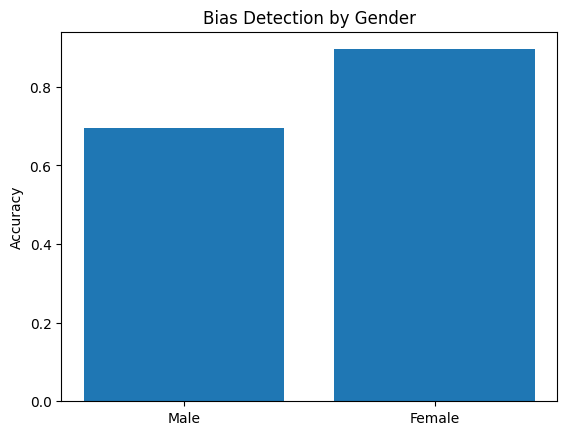

In [43]:
groups = ['Male', 'Female']
accuracy = [male_acc, female_acc]

plt.bar(groups, accuracy)
plt.title("Bias Detection by Gender")
plt.ylabel("Accuracy")
plt.show()

Final Conclusion Print

In [44]:
if abs(male_acc - female_acc) > 0.05:
    print("Bias detected in the model!")
else:
    print("No significant bias detected.")

Bias detected in the model!
